# Intent Classification Model Training
## Chatbot Penerimaan Santri Pondok Pesantren

Dokumen ini berisi langkah-langkah implementasi pembuatan model **Intent Classification** untuk Chatbot Penerimaan Santri Pondok Pesantren. Pendekatan yang digunakan adalah **Classical NLP (TF-IDF + Logistic Regression)** sesuai dengan kebutuhan akademik dan arsitektur hybrid chatbot.

### Tahapan Implementasi:
1. **Persiapan Dataset**: Memuat dan memeriksa data `intents.csv`.
2. **Preprocessing Teks**: Membersihkan teks agar standar.
3. **Feature Engineering**: Mengubah teks menjadi representasi numerik menggunakan TF-IDF.
4. **Label Encoding**: Mengonversi label intent menjadi numerik.
5. **Training Model**: Melatih model Logistic Regression.
6. **Evaluasi Model**: Mengukur performa model (Accuracy, Precision, Recall, F1-Score).
7. **Ekspor Model**: Menyimpan artefak model (`.pkl`).

In [10]:
import pandas as pd
import numpy as np
import re
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB # Added for Multinomial Naive Bayes
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

## 1. Persiapan Dataset
Memuat dataset `intents.csv` dan melakukan eksplorasi data awal.

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Successfully loaded data from /content/drive/MyDrive/Colab Notebooks/NLP - semester 7/PSB Chatbot/intents_v2.csv:


,text,intent
0,Kapan pendaftaran santri baru dibuka tahun ini?,info_pendaftaran
1,Mohon info jadwal penerimaan santri baru pondo...,info_pendaftaran
2,Pendaftaran santri baru biasanya mulai bulan apa?,info_pendaftaran
3,Saya ingin tahu periode pendaftaran gelombang ...,info_pendaftaran
4,Apakah pendaftaran masih dibuka saat ini?,info_pendaftaran


Pratinjau Data:


,text,intent
0,Kapan pendaftaran santri baru dibuka tahun ini?,info_pendaftaran
1,Mohon info jadwal penerimaan santri baru pondo...,info_pendaftaran
2,Pendaftaran santri baru biasanya mulai bulan apa?,info_pendaftaran
3,Saya ingin tahu periode pendaftaran gelombang ...,info_pendaftaran
4,Apakah pendaftaran masih dibuka saat ini?,info_pendaftaran



Jumlah Missing Values:
text      0
intent    0
dtype: int64

Jumlah Data Duplikat: 48


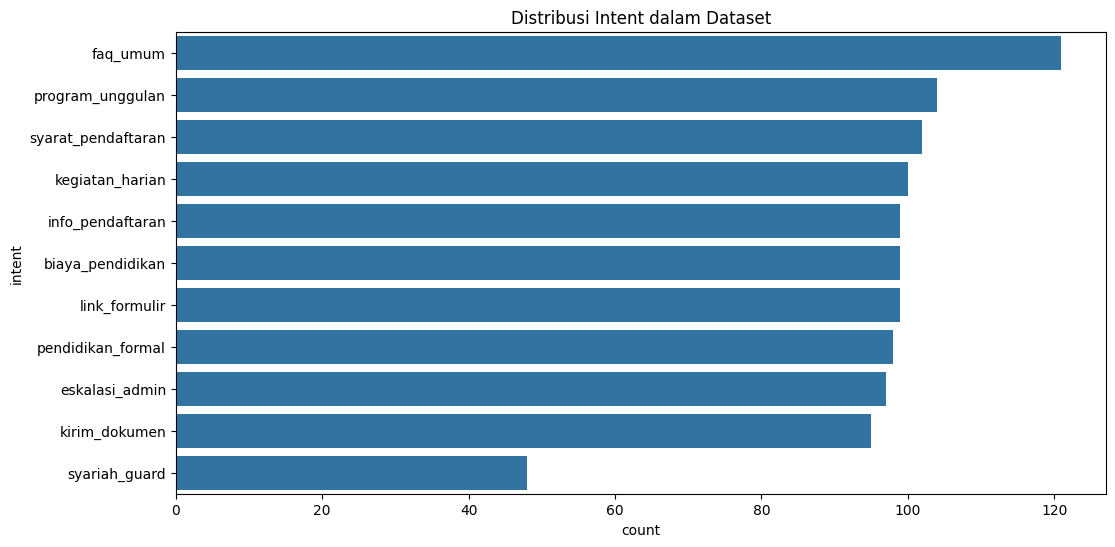

In [12]:
file_path = '/content/drive/MyDrive/Colab Notebooks/NLP - semester 7/PSB Chatbot/intents_v2.csv'

try:
    df = pd.read_csv(file_path, on_bad_lines='skip') # Added on_bad_lines='skip' to handle malformed lines
    print(f"Successfully loaded data from {file_path}:")
    display(df.head())

    # Moved all df-dependent operations inside the try block
    print("Pratinjau Data:")
    display(df.head())

    # Memeriksa missing values dan duplikat
    print(f"\nJumlah Missing Values:\n{df.isnull().sum()}")
    print(f"\nJumlah Data Duplikat: {df.duplicated().sum()}")

    # Distribusi Intent
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, y='intent', order=df['intent'].value_counts().index)
    plt.title('Distribusi Intent dalam Dataset')
    plt.show()

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the path and try again.")
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

## 2. Preprocessing Teks
Melakukan pembersihan teks: mengubah ke lowercase dan menghapus karakter non-alfabet.

In [13]:
def clean_text(text):
    # Mengubah ke lowercase
    text = text.lower()
    # Menghapus tanda baca dan karakter non-alfabet
    text = re.sub(r'[^a-z\s]', '', text)
    # Menghapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Menerapkan fungsi cleaning
df['clean_text'] = df['text'].apply(clean_text)

print("Hasil Preprocessing:")
display(df[['text', 'clean_text']].head())

Hasil Preprocessing:


,text,clean_text
0,Kapan pendaftaran santri baru dibuka tahun ini?,kapan pendaftaran santri baru dibuka tahun ini
1,Mohon info jadwal penerimaan santri baru pondo...,mohon info jadwal penerimaan santri baru pondo...
2,Pendaftaran santri baru biasanya mulai bulan apa?,pendaftaran santri baru biasanya mulai bulan apa
3,Saya ingin tahu periode pendaftaran gelombang ...,saya ingin tahu periode pendaftaran gelombang ...
4,Apakah pendaftaran masih dibuka saat ini?,apakah pendaftaran masih dibuka saat ini


## 3. Feature Engineering (TF-IDF)
Mengubah teks menjadi representasi numerik menggunakan TF-IDF Vectorizer.

In [14]:
# Konfigurasi TF-IDF sesuai arahan
vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(df['clean_text'])
print(f"Dimensi Matriks Fitur: {X.shape}")

Dimensi Matriks Fitur: (1062, 2096)


## 4. Label Encoding
Mengonversi label intent string menjadi numerik.

In [15]:
le = LabelEncoder()
y = le.fit_transform(df['intent'])

print("Mapping Label Intent:")
for i, label in enumerate(le.classes_):
    print(f"{i}: {label}")

Mapping Label Intent:
0: biaya_pendidikan
1: eskalasi_admin
2: faq_umum
3: info_pendaftaran
4: kegiatan_harian
5: kirim_dokumen
6: link_formulir
7: pendidikan_formal
8: program_unggulan
9: syarat_pendaftaran
10: syariah_guard


## 5. Training Model
Membagi data menjadi train-test set dan melatih model Logistic Regression dan Multinomial Naive Baiyes.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Inisialisasi dan training Logistic Regression model
model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)

print("Logistic Regression Model berhasil dilatih.")

# Inisialisasi dan training Multinomial Naive Bayes model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

print("Multinomial Naive Bayes Model berhasil dilatih.")

Logistic Regression Model berhasil dilatih.
Multinomial Naive Bayes Model berhasil dilatih.


## 6. Evaluasi Model
Mengukur performa model menggunakan data uji.


--- Evaluasi Logistic Regression ---
Classification Report (Logistic Regression):
                    precision    recall  f1-score   support

  biaya_pendidikan       1.00      1.00      1.00        20
    eskalasi_admin       0.94      0.89      0.92        19
          faq_umum       0.67      0.92      0.77        24
  info_pendaftaran       1.00      0.95      0.97        20
   kegiatan_harian       1.00      0.90      0.95        20
     kirim_dokumen       1.00      0.95      0.97        19
     link_formulir       1.00      1.00      1.00        20
 pendidikan_formal       0.89      0.85      0.87        20
  program_unggulan       0.91      0.95      0.93        21
syarat_pendaftaran       0.90      0.95      0.93        20
     syariah_guard       1.00      0.50      0.67        10

          accuracy                           0.92       213
         macro avg       0.94      0.90      0.91       213
      weighted avg       0.93      0.92      0.92       213

Accuracy Score

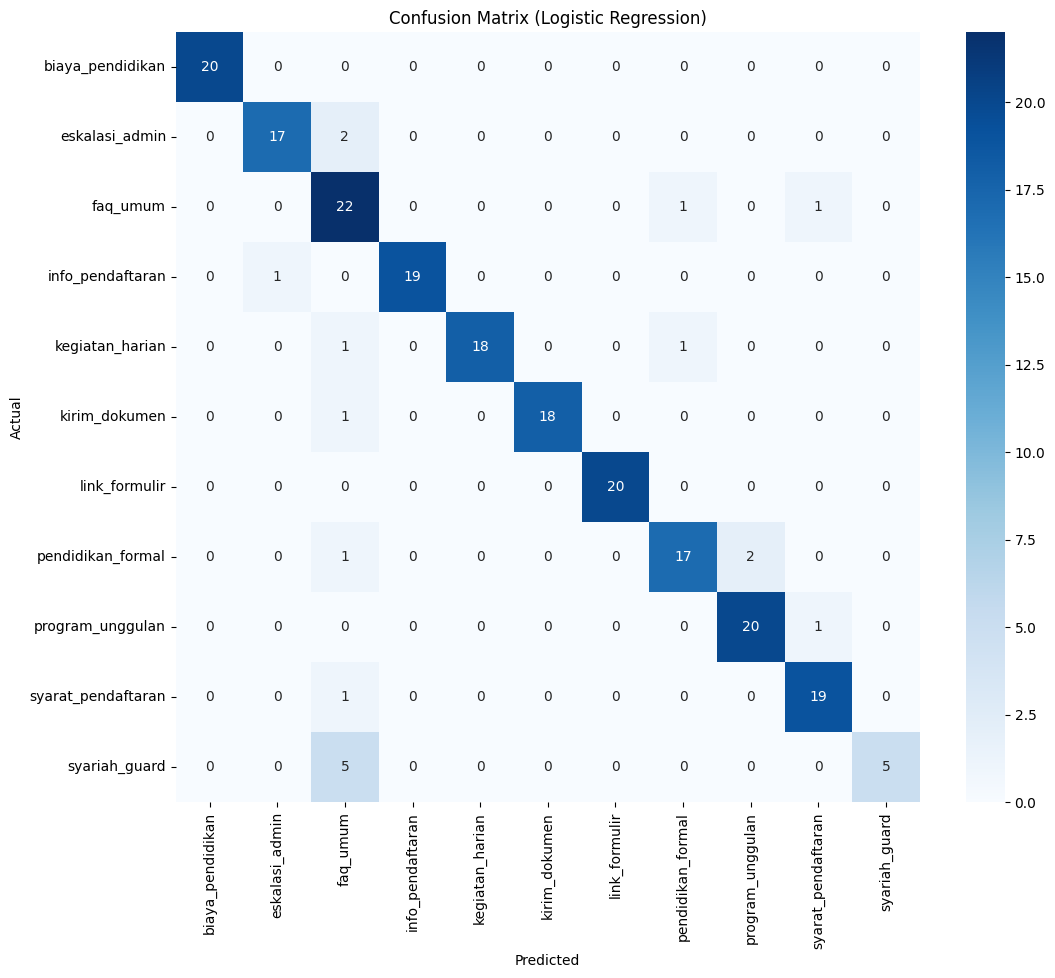


--- Evaluasi Multinomial Naive Bayes ---
Classification Report (Multinomial Naive Bayes):
                    precision    recall  f1-score   support

  biaya_pendidikan       0.91      1.00      0.95        20
    eskalasi_admin       0.82      0.95      0.88        19
          faq_umum       0.79      0.92      0.85        24
  info_pendaftaran       1.00      0.75      0.86        20
   kegiatan_harian       1.00      0.85      0.92        20
     kirim_dokumen       0.95      1.00      0.97        19
     link_formulir       0.95      1.00      0.98        20
 pendidikan_formal       0.89      0.85      0.87        20
  program_unggulan       0.81      1.00      0.89        21
syarat_pendaftaran       0.95      0.95      0.95        20
     syariah_guard       1.00      0.30      0.46        10

          accuracy                           0.90       213
         macro avg       0.92      0.87      0.87       213
      weighted avg       0.91      0.90      0.89       213

Accura

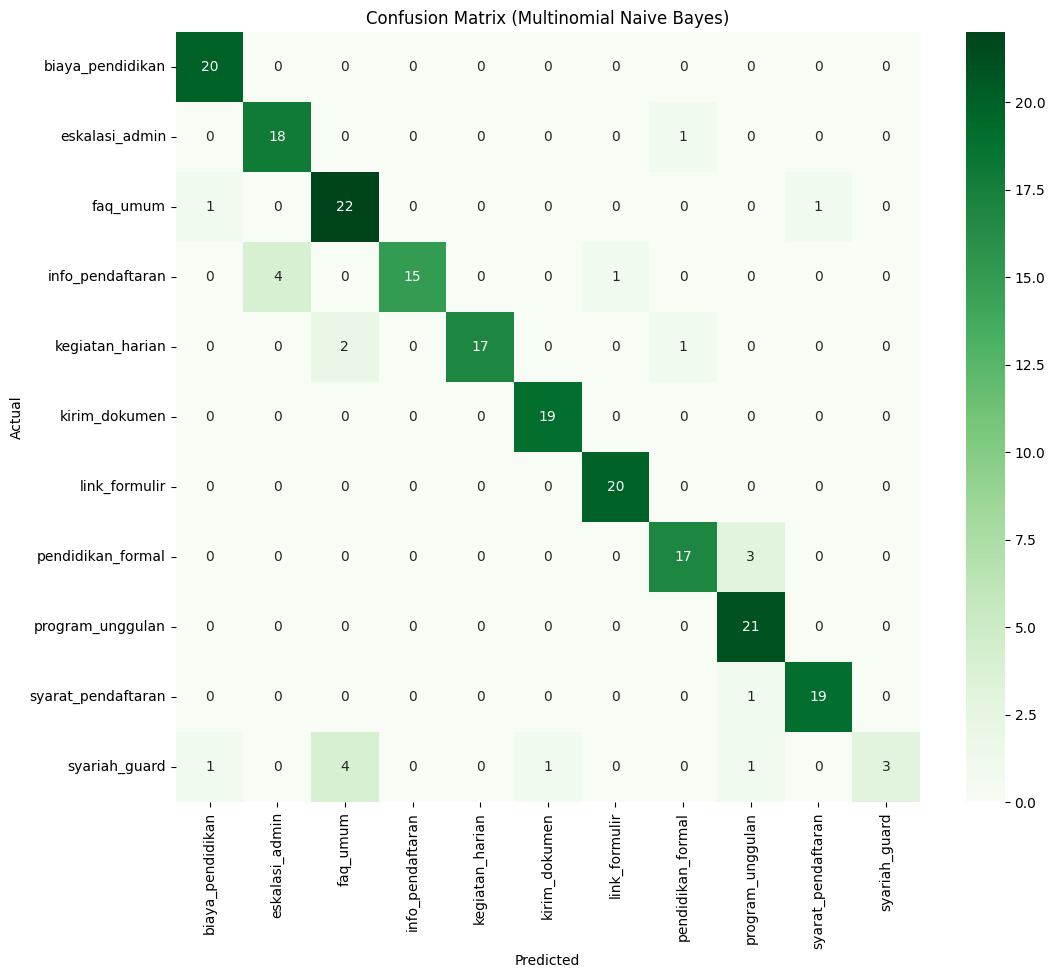

In [21]:

# Prediksi data uji untuk Logistic Regression
y_pred = model.predict(X_test)

print("\n--- Evaluasi Logistic Regression ---")
# Metrik Evaluasi Logistic Regression
print("Classification Report (Logistic Regression):")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print(f"Accuracy Score (Logistic Regression): {accuracy_score(y_test, y_pred):.4f}")

# Confusion Matrix Logistic Regression
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Logistic Regression)')
plt.show()

# Prediksi data uji untuk Multinomial Naive Bayes
y_pred_nb = nb_model.predict(X_test)

print("\n--- Evaluasi Multinomial Naive Bayes ---")
# Metrik Evaluasi Multinomial Naive Bayes
print("Classification Report (Multinomial Naive Bayes):")
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))
print(f"Accuracy Score (Multinomial Naive Bayes): {accuracy_score(y_test, y_pred_nb):.4f}")

# Confusion Matrix Multinomial Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Multinomial Naive Bayes)')
plt.show()

## 7. Uji Coba Prediksi (Inference)
Menguji model dengan input teks baru untuk mendapatkan intent dan confidence score.

In [22]:

def predict_intent_lr(text):
    # Preprocessing
    cleaned = clean_text(text)
    # Vectorization
    features = vectorizer.transform([cleaned])
    # Prediction
    probs = model.predict_proba(features)[0]
    max_prob_idx = np.argmax(probs)

    intent = le.inverse_transform([max_prob_idx])[0]
    confidence = probs[max_prob_idx]

    return intent, confidence

def predict_intent_nb(text):
    # Preprocessing
    cleaned = clean_text(text)
    # Vectorization
    features = vectorizer.transform([cleaned])
    # Prediction
    probs = nb_model.predict_proba(features)[0]
    max_prob_idx = np.argmax(probs)

    intent = le.inverse_transform([max_prob_idx])[0]
    confidence = probs[max_prob_idx]

    return intent, confidence

# Contoh pengujian
test_queries = [
    "Berapa biaya masuk pesantren ini?",
    "Kapan pendaftaran dibuka?",
    "Saya ingin bicara dengan admin",
    "Apa saja syarat pendaftarannya?"
]

print("Hasil Uji Coba Prediksi (Logistic Regression):")
for query in test_queries:
    intent, conf = predict_intent_lr(query)
    print(f"Query: {query}")
    print(f"Intent: {intent} (Confidence: {conf:.4f})")

print("\nHasil Uji Coba Prediksi (Multinomial Naive Bayes):")
for query in test_queries:
    intent, conf = predict_intent_nb(query)
    print(f"Query: {query}")
    print(f"Intent: {intent} (Confidence: {conf:.4f})")

Hasil Uji Coba Prediksi (Logistic Regression):
Query: Berapa biaya masuk pesantren ini?
Intent: biaya_pendidikan (Confidence: 0.6705)
Query: Kapan pendaftaran dibuka?
Intent: info_pendaftaran (Confidence: 0.6927)
Query: Saya ingin bicara dengan admin
Intent: eskalasi_admin (Confidence: 0.8780)
Query: Apa saja syarat pendaftarannya?
Intent: syarat_pendaftaran (Confidence: 0.8756)

Hasil Uji Coba Prediksi (Multinomial Naive Bayes):
Query: Berapa biaya masuk pesantren ini?
Intent: biaya_pendidikan (Confidence: 0.5031)
Query: Kapan pendaftaran dibuka?
Intent: info_pendaftaran (Confidence: 0.5755)
Query: Saya ingin bicara dengan admin
Intent: eskalasi_admin (Confidence: 0.8908)
Query: Apa saja syarat pendaftarannya?
Intent: syarat_pendaftaran (Confidence: 0.6909)


## 8. Ekspor Model (Artefak NLP)
Menyimpan model, vectorizer, dan label encoder ke dalam file `.pkl`.

In [23]:
import os


# Membuat direktori models jika belum ada
os.makedirs('models', exist_ok=True)

# Menyimpan artefak Logistic Regression
with open('models/lr_intent_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Menyimpan artefak Multinomial Naive Bayes
with open('models/nb_intent_model.pkl', 'wb') as f:
    pickle.dump(nb_model, f)

with open('models/vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

with open('models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Artefak model berhasil disimpan di direktori 'models/'.")

Artefak model berhasil disimpan di direktori 'models/'.
